In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

NVIDIA H200
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    if gethostname().startswith("max-"):
        jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    else:
        jax.config.update("jax_compilation_cache_dir", "/fred/oz440/max/jax_cache")

    jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 250
intermediate_prints = []
# intermediate_prints = [100, 250, 2000]
# intermediate_prints = list(range(1000, 19000, 2000))
n_files_per_filt = 3
one_filt_flag = False
binary_flag = False
val_flag = False
flat_flag = True
flat_only = False
# plot_flag = True
plot_flag = check_script()
save_flag = check_script()
recalculate_flag = False


if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-94
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [3]:
from retrain_fns import summarise_files
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)

# # Add extra bad pixels
# badpix = np.load(f"{cache_dir}/full_badpix.npy")
# # badpix = np.load(f"{cache_dir}/full_badpix.npy")
# badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file


## Validation files
Calibrators from other science programs

In [4]:
def sort_files(files):
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}
    for filt in filts:
        x = []
        for file in files:
            if file[0].header["FILTER"] == filt:
                if one_filt_flag and filt != "F480M":
                    continue
                x.append(file)
        these_files[filt] = x[0:n_files_per_filt]
    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

In [5]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []

# Collated validator subset
program_path = os.path.join(data_dir, "VAL_SUBSET/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = sort_files(files)
val_files += files

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

  program            target filter dither     g/i        date                 PI   CAL
0    1093          HD-36805  F480M    1/2    9/65  23-05-2022  Thatte, Deepashri  True
1    1093          HD-36805  F430M    1/2    6/82  23-05-2022  Thatte, Deepashri  True
2    1093          HD-36805  F480M    1/1    9/65  05-06-2022  Thatte, Deepashri  True
3    1093          HD-36805  F380M    1/1   3/122  05-06-2022  Thatte, Deepashri  True
4    1843         HD-205827  F380M    1/1  3/7800  26-10-2022     Kammerer, Jens  True
5    1843         HD-205827  F430M    1/1  7/1885  26-10-2022     Kammerer, Jens  True
6    1242  TD-CAL-HD-123991  F480M    1/1  29/418  24-02-2023    Johnstone, Doug  True
7    1242  TD-CAL-HD-123991  F430M    1/1  20/507  24-02-2023    Johnstone, Doug  True
8    1242  TD-CAL-HD-123991  F380M    1/1  10/612  24-02-2023    Johnstone, Doug  True


# Exposures

In [6]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
exposures = [PointFit(file) for file in val_files]

print(f"Total number of exposures: {len(exposures)}")

# just closing the files
_ = [f.close() for f in val_files]

Total number of exposures: 9


Finally, let's batch the exposures for training.

# Building model

In [7]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

Populate from state.

In [8]:
state = load_dict(amigo_files_path + "/calibration.npy")
# best_state = load_dict(amigo_files_path + "/final_statev03.npy")
best_state = load_dict(amigo_files_path + "/best_state05.npy")
# best_state = load_dict("test_state.npy")
# best_state = load_dict(amigo_files_path + "/final_state.npy")

if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
    del state["jitter"]
    
for key, value in state.items():
    print(key)
    if key in [
        'aberrations',
        'primary_beam',
        'distortion',
        'transmission',
        'badpix',
    ]:
        continue
    model = model.set(key, value)

if not flat_only:
    ab_dict = {}
    for key, _ in model.aberrations.items():
        prog, filt = key.split("_")
        ab_dict[key] = state["aberrations"][filt]
    
    model = model.set("aberrations", ab_dict)

print()
for key, value in best_state.items():
    print(key)
    if key in [
        'nn_weights',
        'primary_beam',
        'distortion',
        'FF',
        'non_linearity',
        # 'spectra',
        'sigma',
        'defocus',
        'dark_current',
    ]:
        # continue
        model = model.set(key, value)

# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

FF
SRF
non_linearity
dark_current
defocus
nn_weights
aberrations
transmission
badpix
sigma

FF
aberrations
dark_current
defocus
distortion
flat_coeffs
fluxes
non_linearity
positions
primary_beam
sigma
spectra
nn_weights


## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

Now the validator exposures.

In [9]:
# from amigo.plotting import summarise_fit

# if save_flag:
#     this_save_path = os.path.join(save_path, "init_val")
#     os.mkdir(this_save_path)
# else:
#     this_save_path = None
# for exp in exposures:
#     print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints, exp.filename)
#     summarise_fit(model, exp, save_path=this_save_path)

Finally, the flats and darks.

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [10]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    # grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    temp_decay,
    cosine_warmup,
)

from retrain_fns import get_warmup, get_temperature


def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    # flat field
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    # non linearity
    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    # spectra clipping
    if hasattr(model_params, "spectra"):
        spectra = model_params.spectra
        clip_fn = lambda x: np.clip(x, a_min=-0.8, a_max=0.8)
        spectra = jax.tree.map(clip_fn, spectra)
        model_params = model_params.set("spectra", spectra)

    return model_params, args


def grads_fn(model, grads, args):

    # Get the parameters
    grad_params = grads.params
    
    if "nn_weights" not in grad_params.keys():
        return grads, args

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]
    temp = get_temperature(args)
    rand_vals = temp * jr.normal(key, values.shape)
    values += rand_vals

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)

    return grads, args

# REGULARISATION
reg_dict = {
    "FF": (1.0, ff_reg),
    "NL": (1.0, nl_reg),
}

Instantiating trainer class and updating fishers.

In [11]:
from amigo.calibration import ValBatchedTrainer, Trainer  # , looper_fn, aux_fn
from dorito.stats import apply_regularisers
from retrain_fns import summarise_fn

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer_class = Trainer

trainer_class_kwargs = {
    "loss_fn": loss_fn,
    # "args_fn": args_fn,
    "grad_fn": grads_fn,
    "norm_fn": norm_fn,
    "summarise_fn": summarise_fn,
    "intermediate_prints": intermediate_prints,
    "save_path": save_path,
    "cache": cache_dir,
}


if val_flag:
    trainer_class_kwargs["aux_fn"] = aux_fn
    trainer_class_kwargs["looper_fn"] = looper_fn
    

trainer = trainer_class(**trainer_class_kwargs)


trainer = trainer.update_fishers(
    linear_model,
    exposures,
    batch_size=10,
    parameters=[
        # "distortion",
        # "primary_beam",
        # "defocus",
        "aberrations",
    ],
    recalculate=recalculate_flag,
    overwrite=recalculate_flag,
)

trainer = trainer.update_fishers(
    linear_model,
    exposures,
    parameters=[
        "positions",
        "fluxes",
        "spectra",
        # "sigma",  # formerly jitter
        # "dark_current",
    ],
    recalculate=recalculate_flag,
    overwrite=recalculate_flag,
)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Training.

In [12]:
from amigo.fitting import sgd, adam, batch_exposures

# Define the optimisers
optimisers = {
    "fluxes": sgd(1e-3, 0),
    "positions": sgd(1e-3, 2),
    "aberrations": sgd(1e-4, 5),
    # "nn_weights": sgd(1e-5, 0),  # lr applied with warm up
    # "defocus": sgd(1e-3, 25),
    # "distortion": sgd(5e-5, 30),
    # "dark_current": sgd(2e-3, 35),
    # "primary_beam": sgd(1e-5, 40),
    # "sigma": sgd(1e-3, 50),  # start at 50th?
    # "non_linearity": sgd(1e-4, 100),
    # "FF": sgd(2e-5, 150),
    "spectra": sgd(1e-3, 100),
}

if not binary_flag:
    bin_ps = ["pas", "separations", "contrasts"]
    optimisers = {key: val for key, val in optimisers.items() if key not in bin_ps}

if not flat_flag:
    flat_ps = ["flat_coeffs"]
    optimisers = {key: val for key, val in optimisers.items() if key not in flat_ps}    
        
print(optimisers.keys())
# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

common_trainer_kwargs = {
    "model": model,
    "optimisers": optimisers,
    "epochs": epochs,
    "batches": batch_exposures(exposures, batch_size=3, key="val"),
    # "args": args,
    # "summarise_kwargs": summarise_kwargs,
}

# with jax.disable_jit():
result = trainer.train(**common_trainer_kwargs)

dict_keys(['fluxes', 'positions', 'aberrations', 'spectra'])


  0%|          | 0/250 [00:00<?, ?it/s]

Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling update function...

Initial_loss Loss: 6,438.70
Estimated run time: 0:13:21
Full Time: 0:20:05
Final Loss: 88.47


Plotting the results of that fit!

# Saving results

# Plotting results

## Loss curves

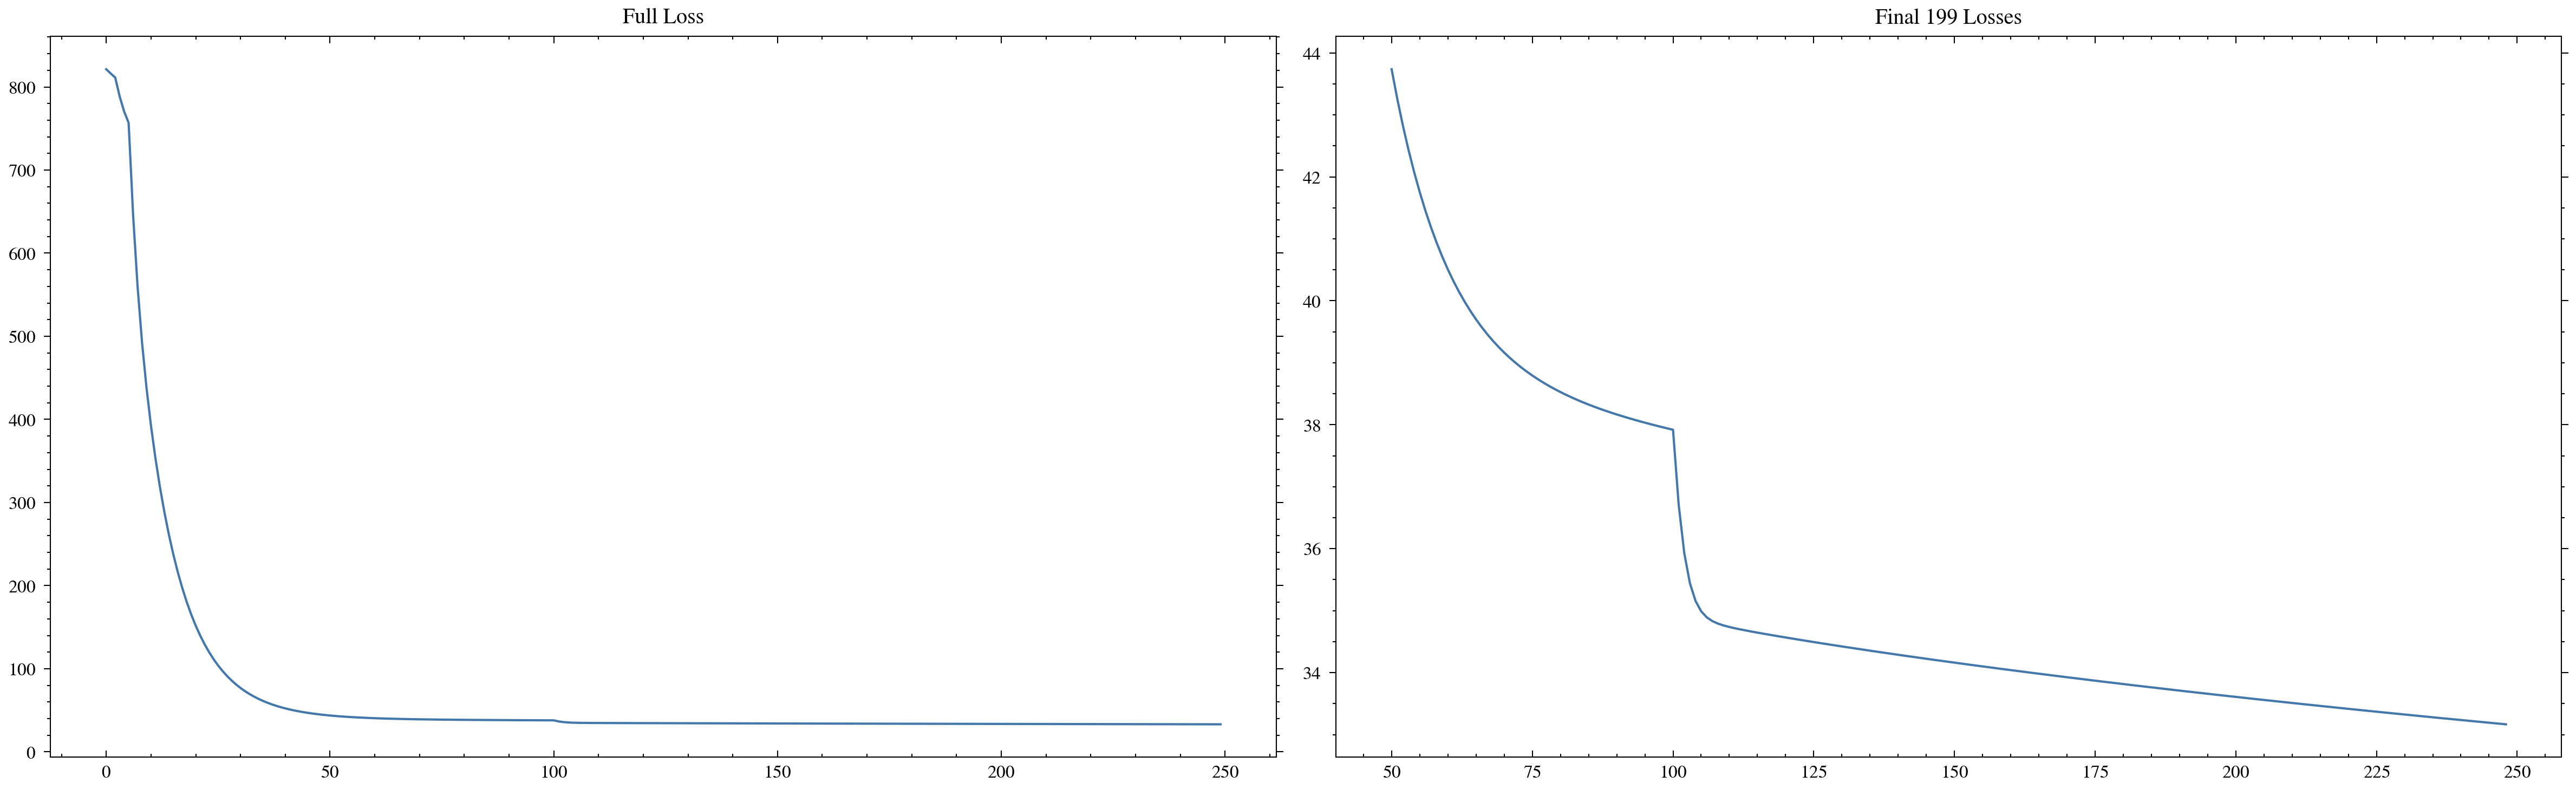

In [13]:
start, stop = 50, -1

if val_flag:
    #
    # epochs = cal.shape[-1]
    # start, stop = 500, -1
    
    if start >= cal.shape[-1]:
        start = 1
    
    if stop < 0:
        stop = cal.shape[-1] + stop
    xs = np.arange(start, stop)
    
    # print(np.array(cal).mean(0)[xs].shape)
    
    plt.figure(figsize=(18, 4))
    ax = plt.subplot(1, 3, 1)
    plt.plot(xs, np.array(cal).mean(0)[xs])
    ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
    
    ax = plt.subplot(1, 3, 2)
    ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
    if val_flag:
        plt.plot(xs, np.array(val).mean(0)[xs])
    
    ax = plt.subplot(1, 3, 3)
    ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
    if flat_flag:
        plt.plot(xs, np.array(flat).mean(0)[xs])
    
    plt.tight_layout()
    if save_flag:
        plt.savefig(os.path.join(save_path, "mean_losses.png"), dpi=200)
    plt.show()
    
    ###
    
    plt.figure(figsize=(18, 4))
    ax = plt.subplot(1, 3, 1)
    ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
    [plt.plot(xs, ys[xs]) for ys in cal]
    
    ax = plt.subplot(1, 3, 2)
    if val_flag:
        ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
    [plt.plot(xs, ys[xs]) for ys in val]
    
    ax = plt.subplot(1, 3, 3)
    ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
    if flat_flag:
        [plt.plot(xs, ys[xs]) for ys in flat]
    
    plt.tight_layout()
    if save_flag:
        plt.savefig(os.path.join(save_path, "all_losses.png"), dpi=200)
    plt.show()

else:
    amigo.plotting.plot_losses(list(result.losses.values())[0], start=start, save_path=save_path)
    

## Residuals and parameter curves

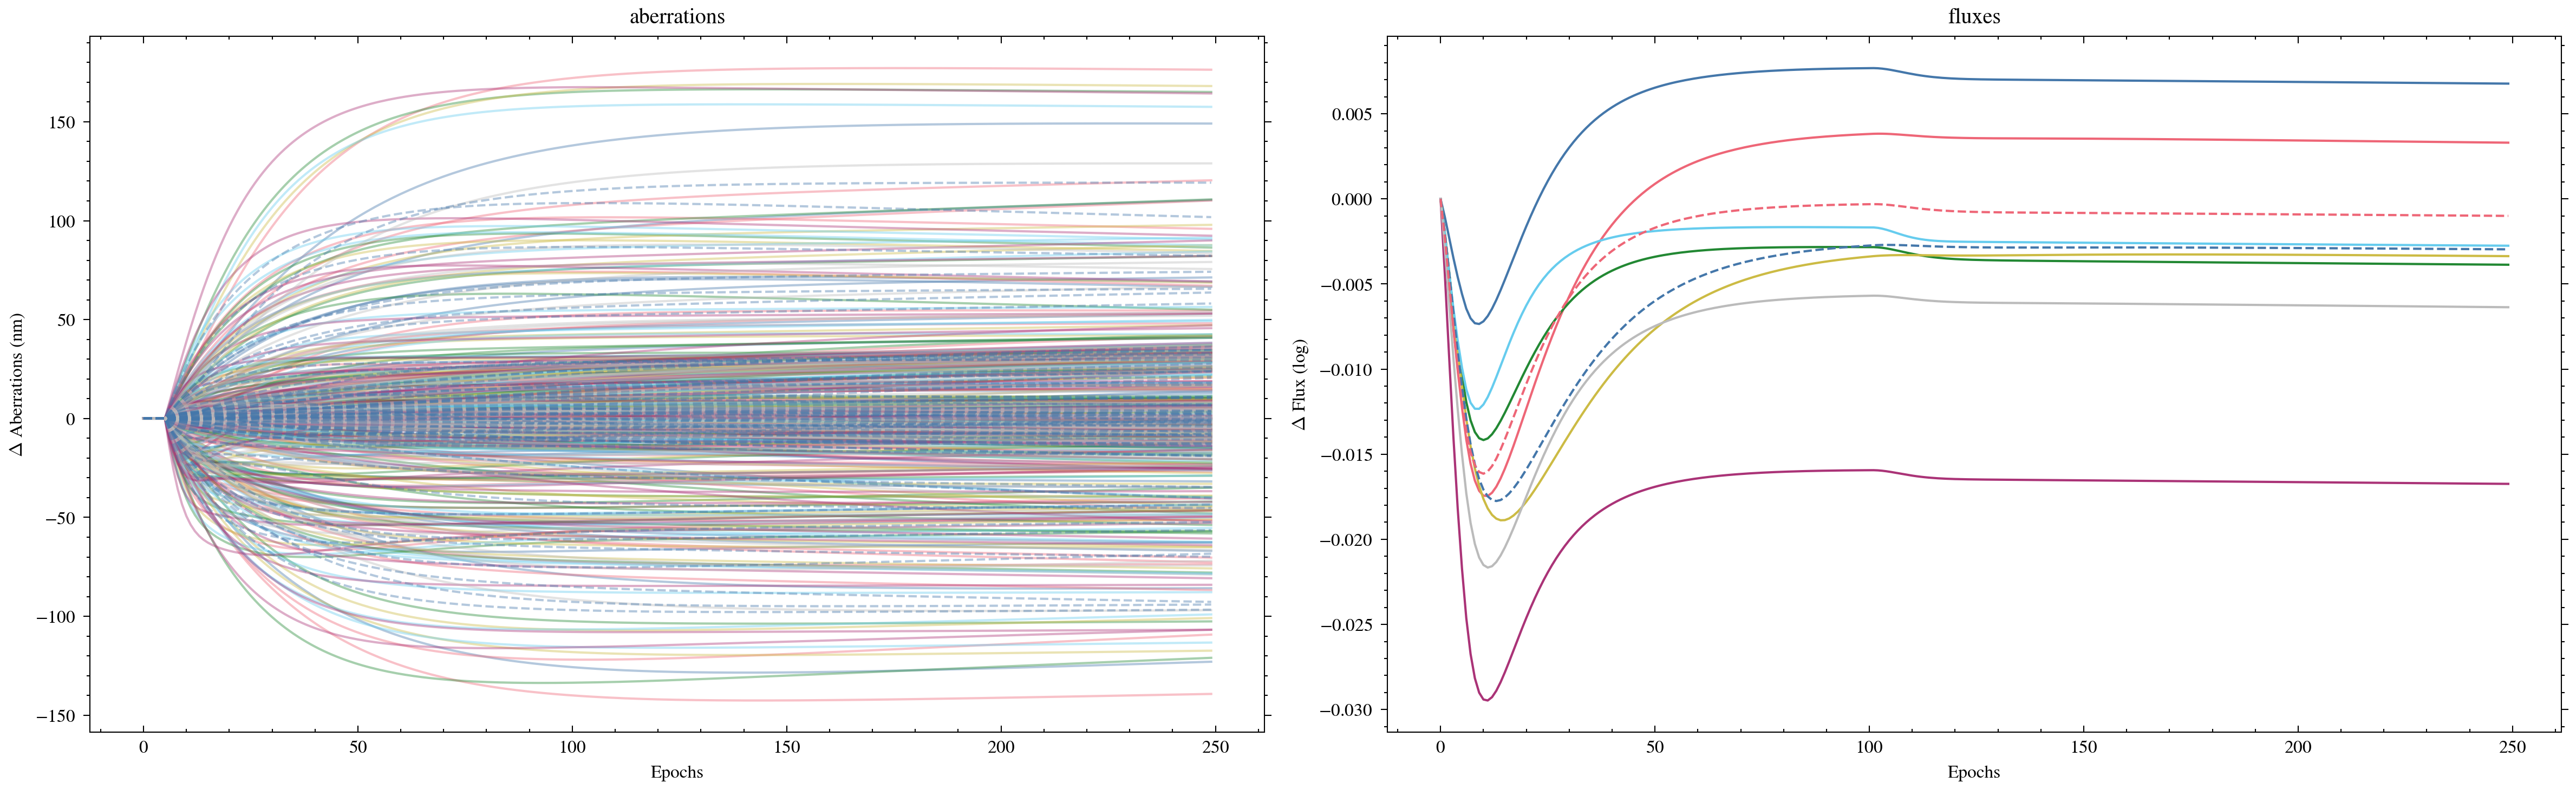

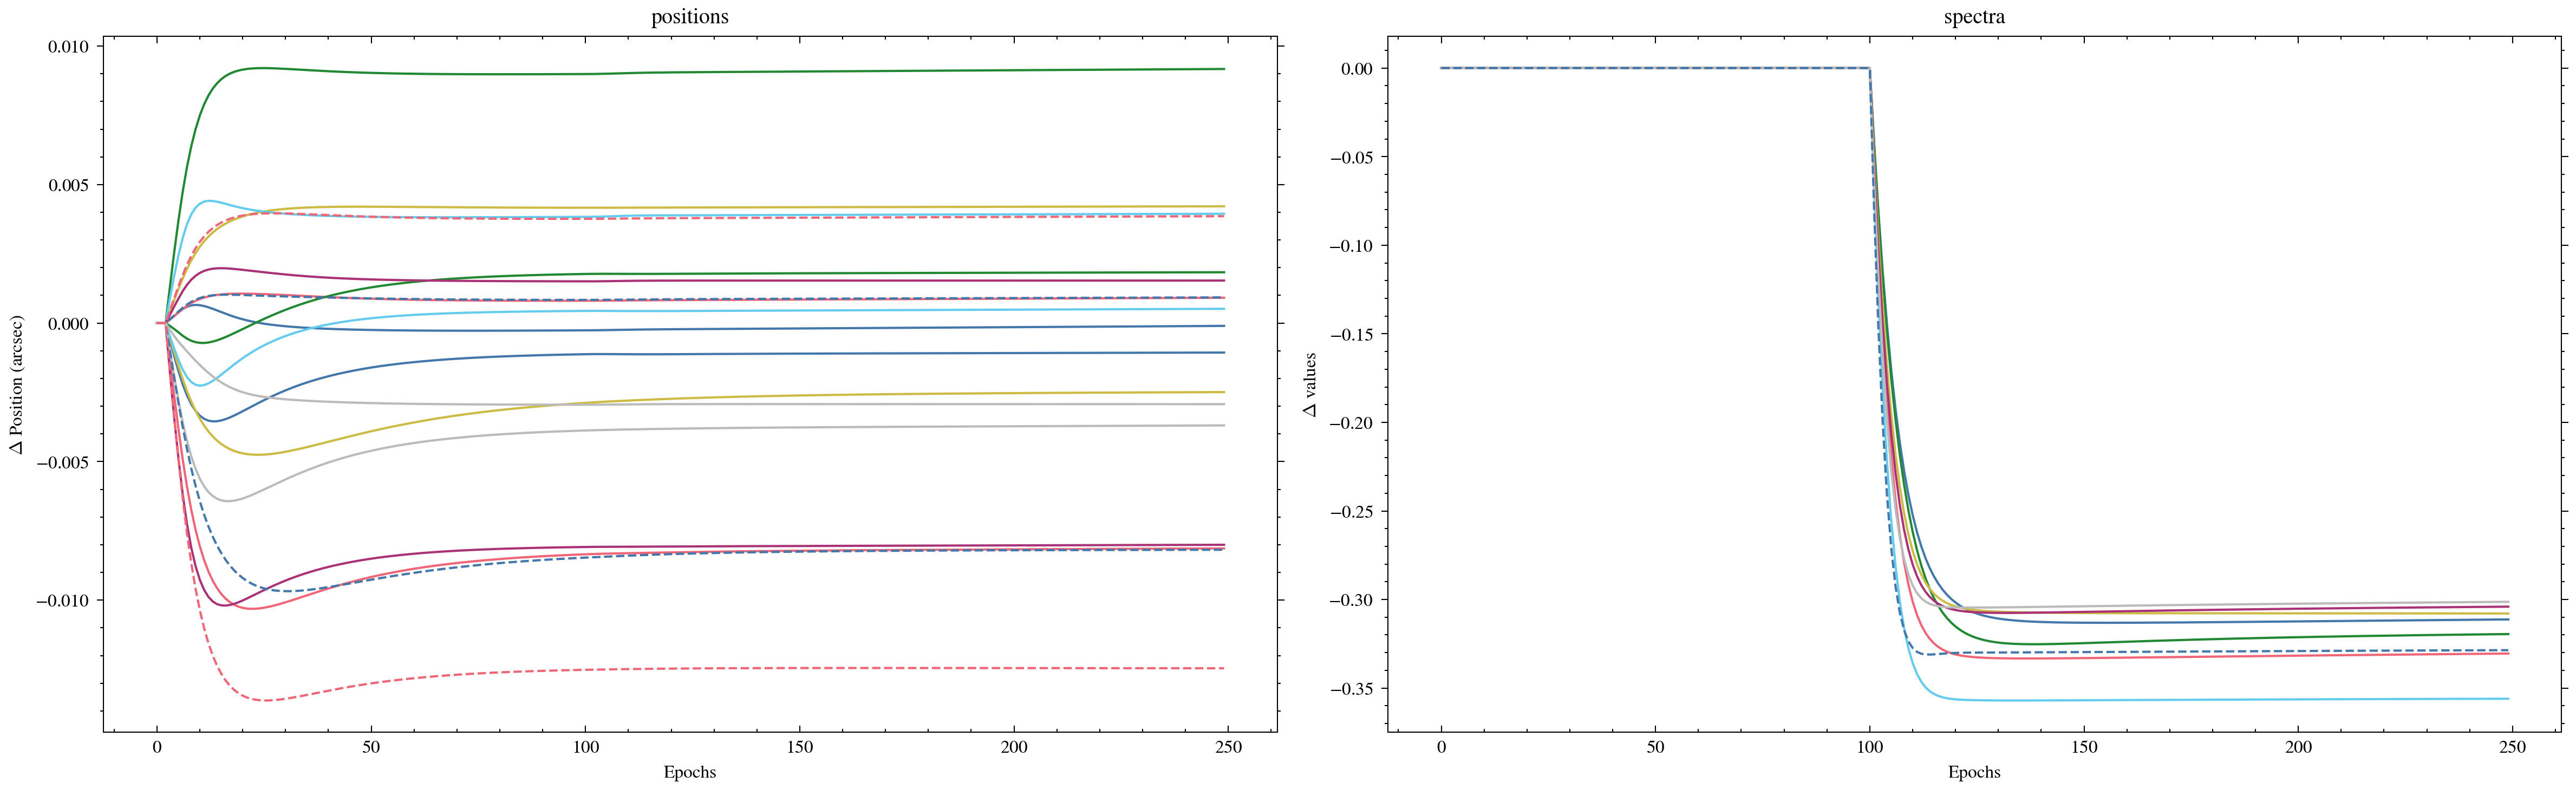

File 01093_018_02_03_1
Star HD-36805
Filter F480M
nints 65
ngroups 9



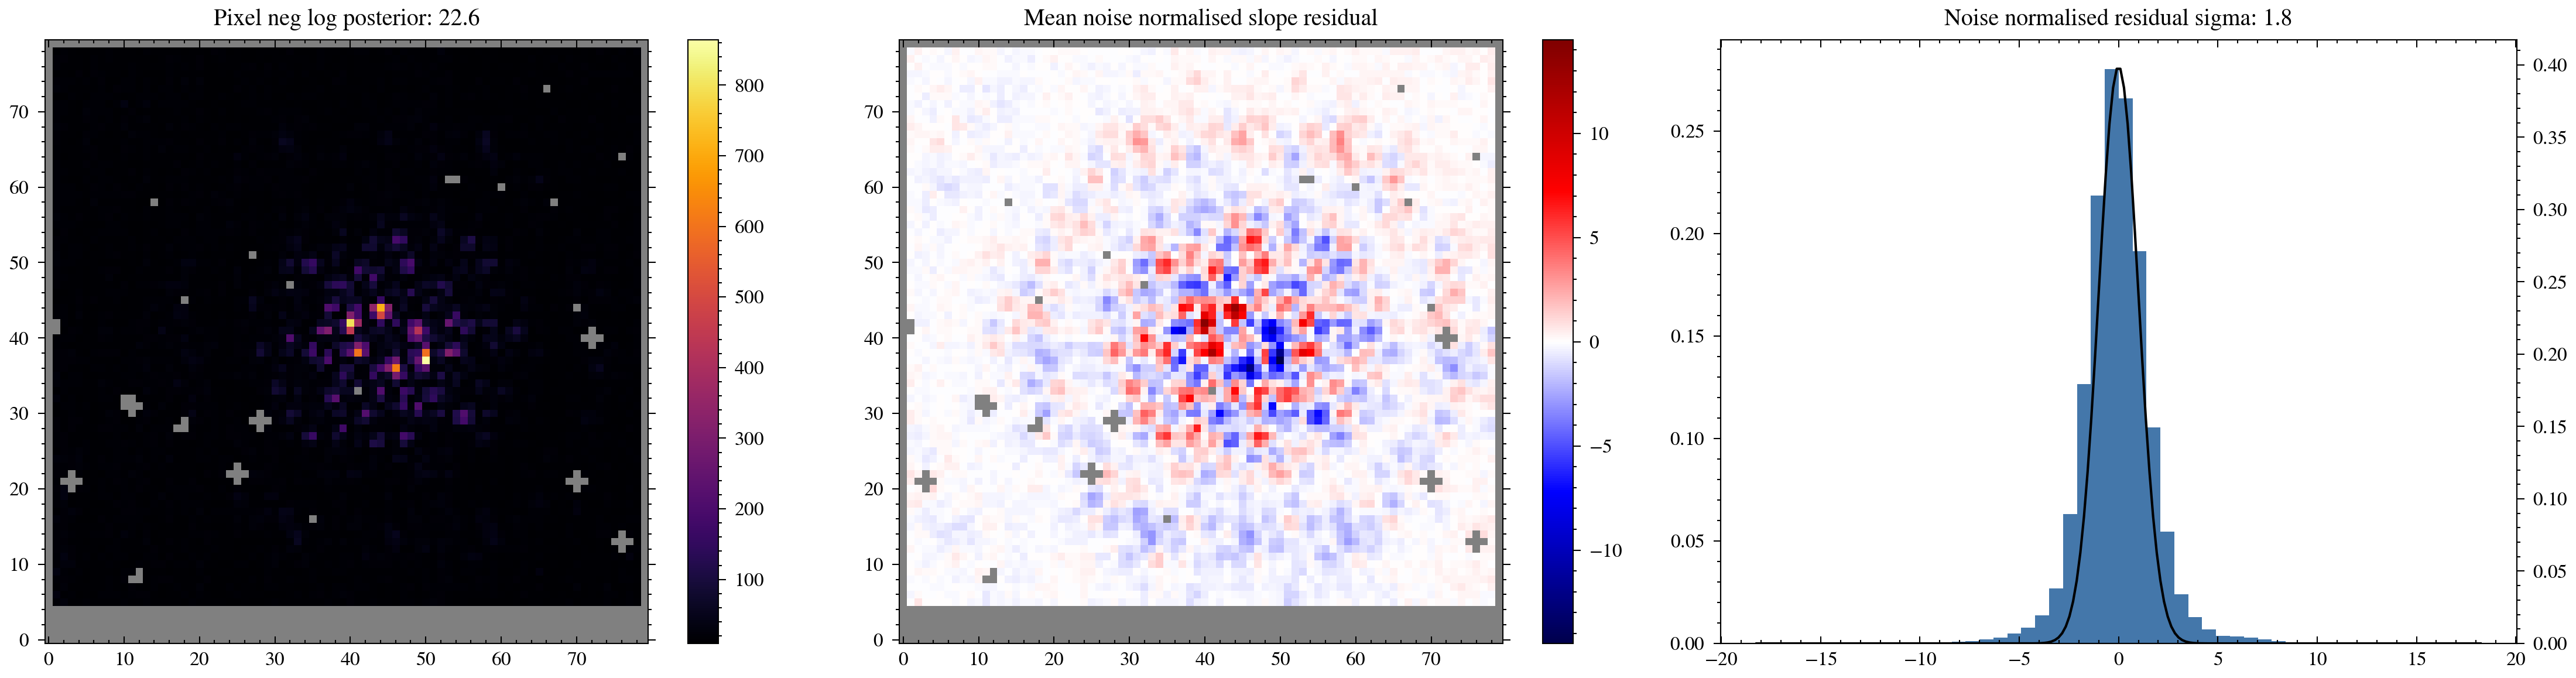

File 01093_006_02_03_1
Star HD-36805
Filter F480M
nints 65
ngroups 9



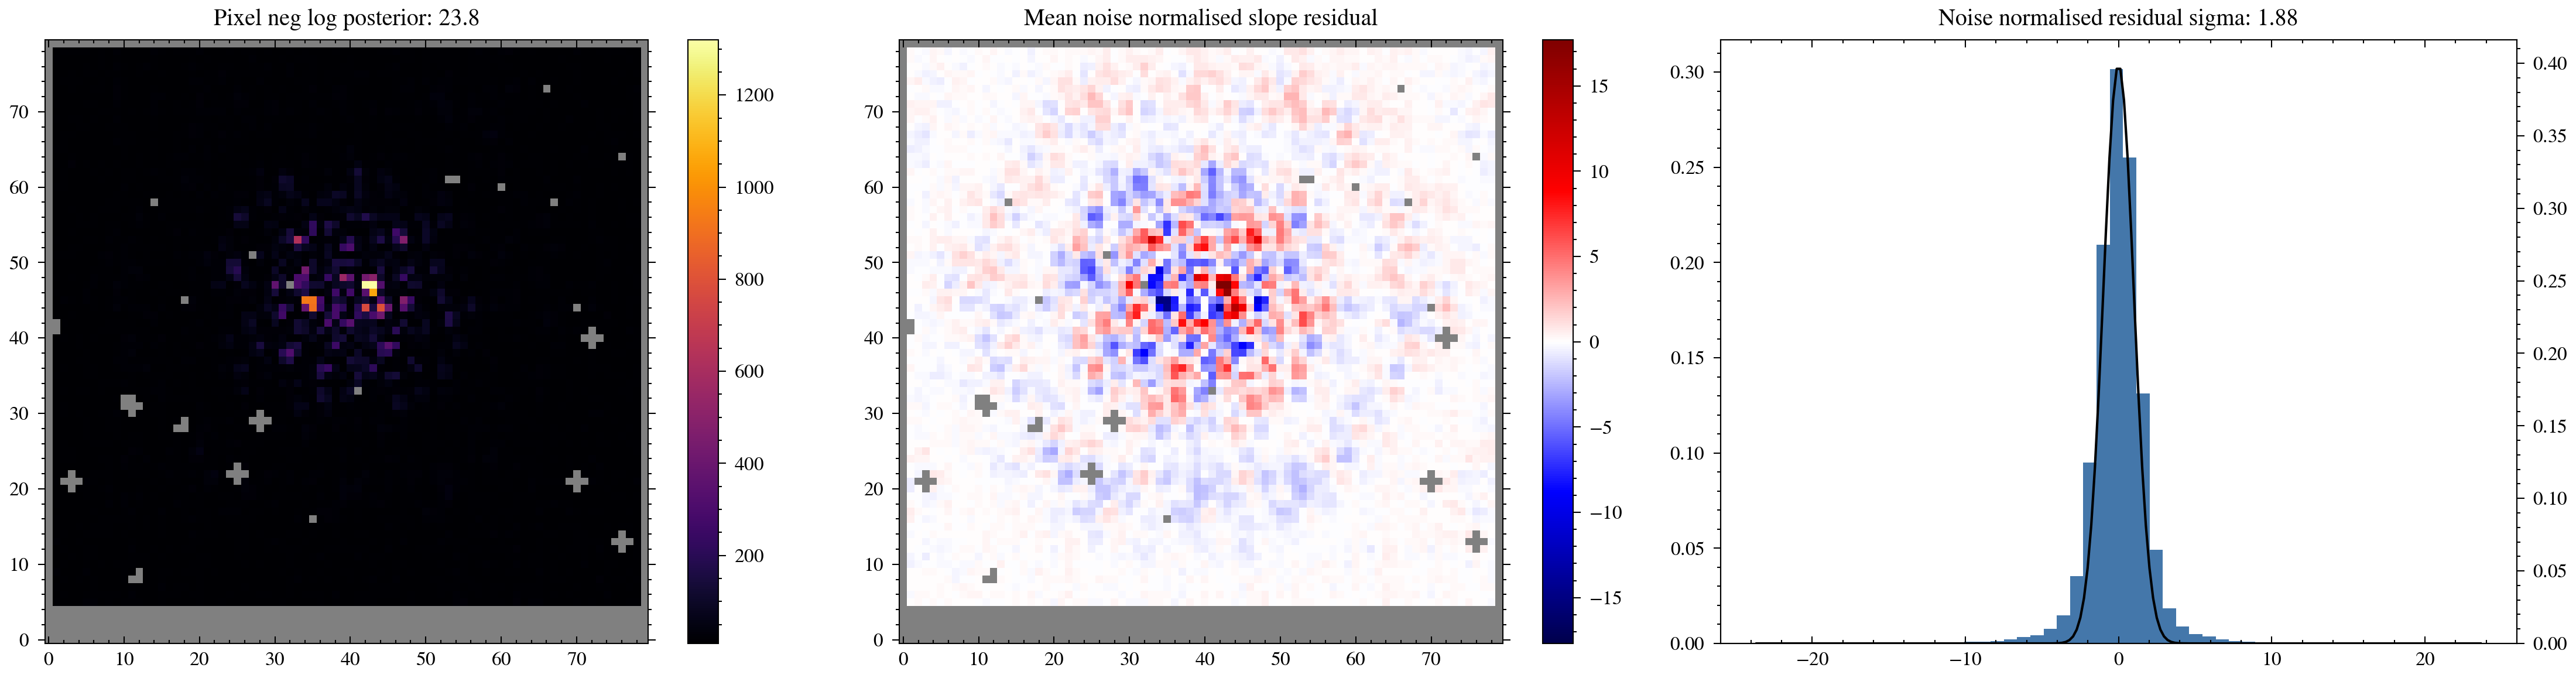

File 01242_004_02_03_1
Star TD-CAL-HD-123991
Filter F480M
nints 418
ngroups 29



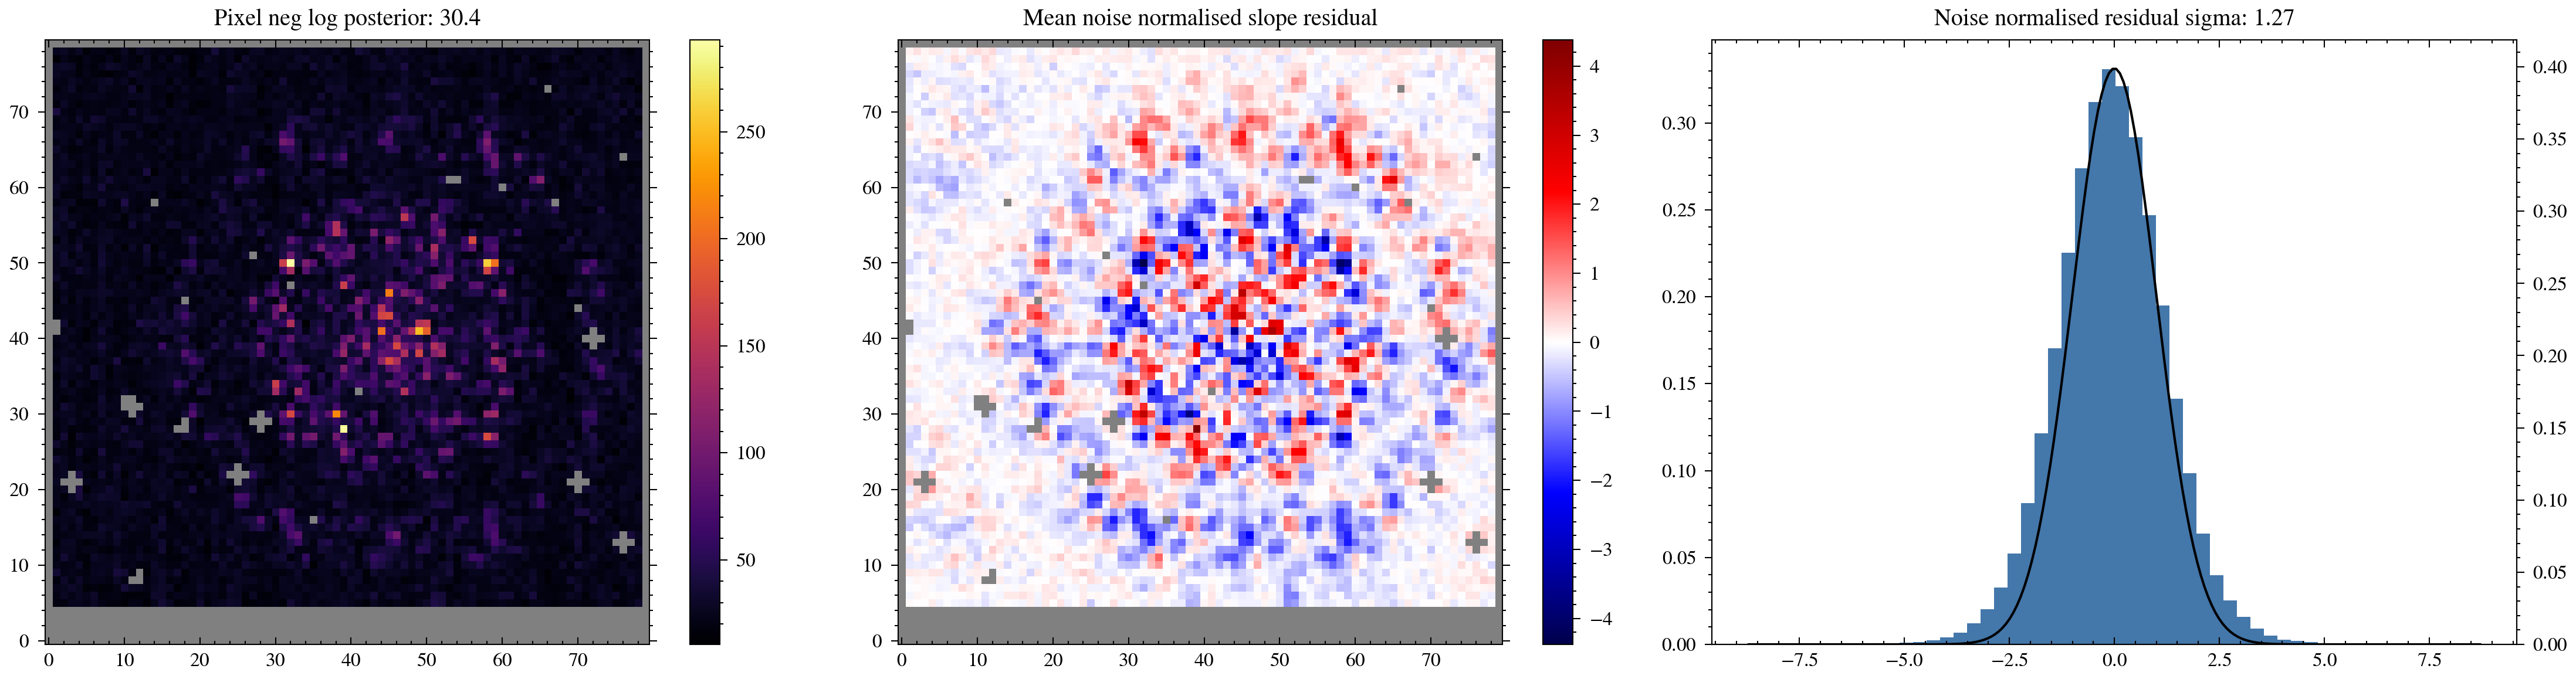

File 01843_002_01_06_1
Star HD-205827
Filter F430M
nints 1885
ngroups 7



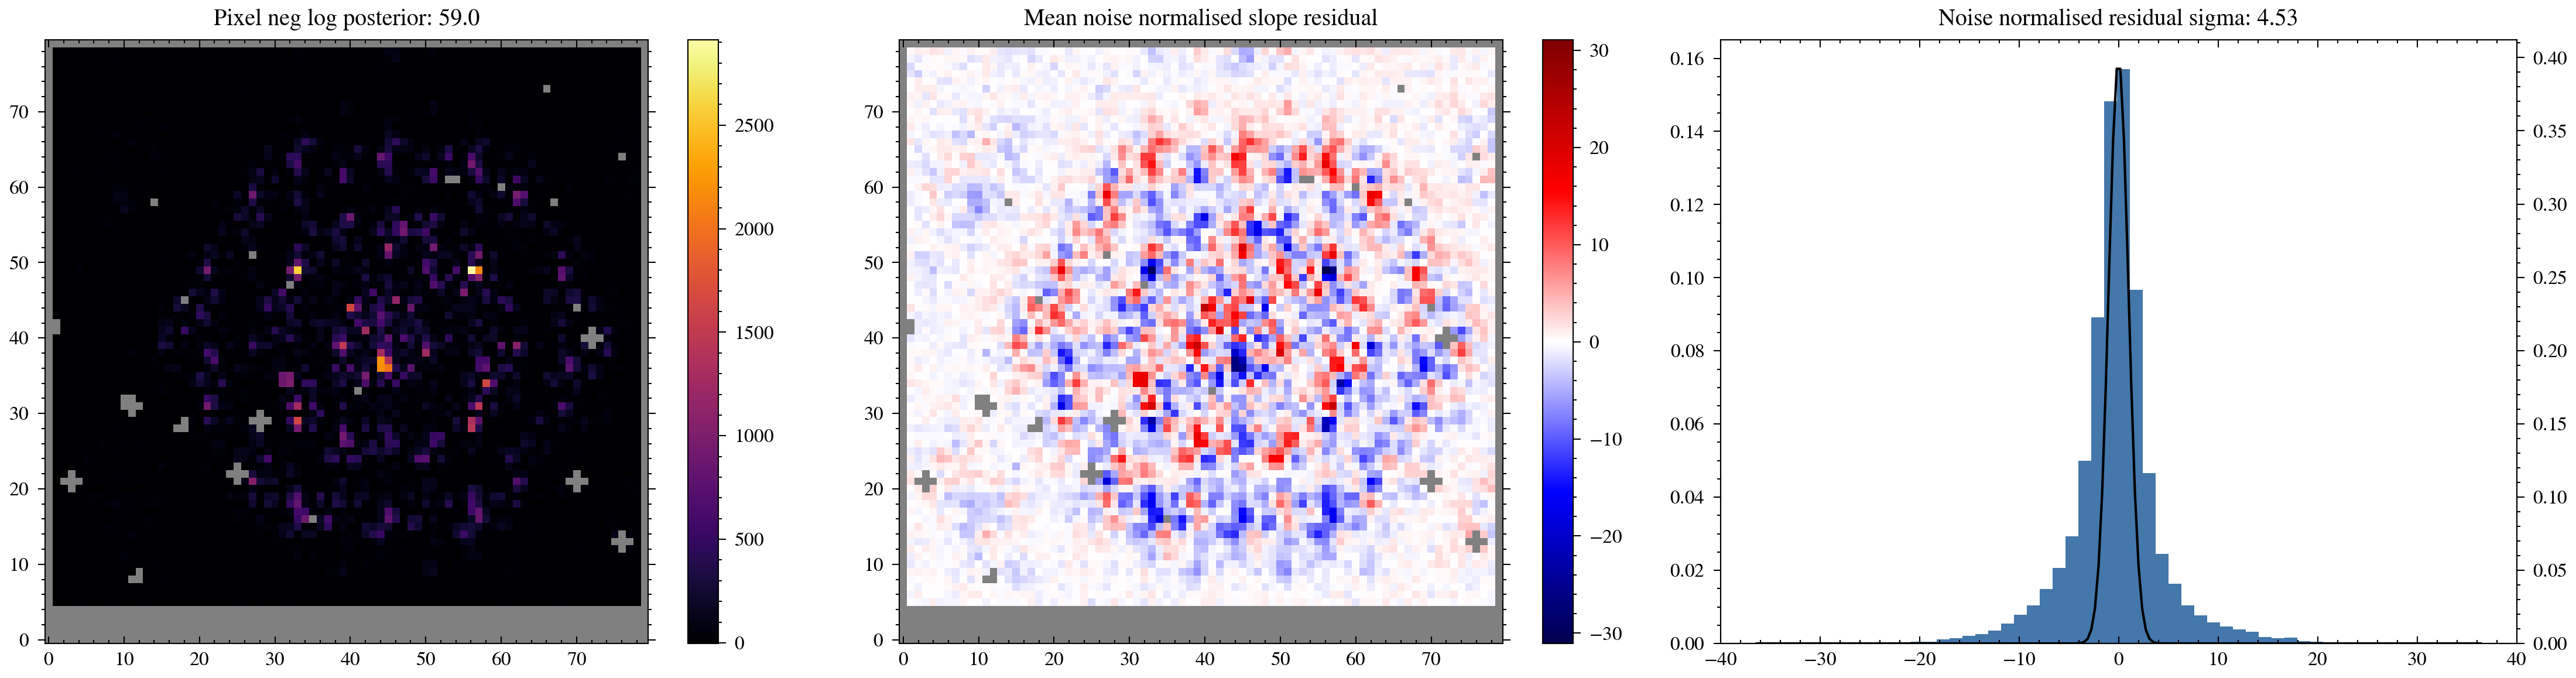

File 01093_006_04_03_1
Star HD-36805
Filter F430M
nints 82
ngroups 6



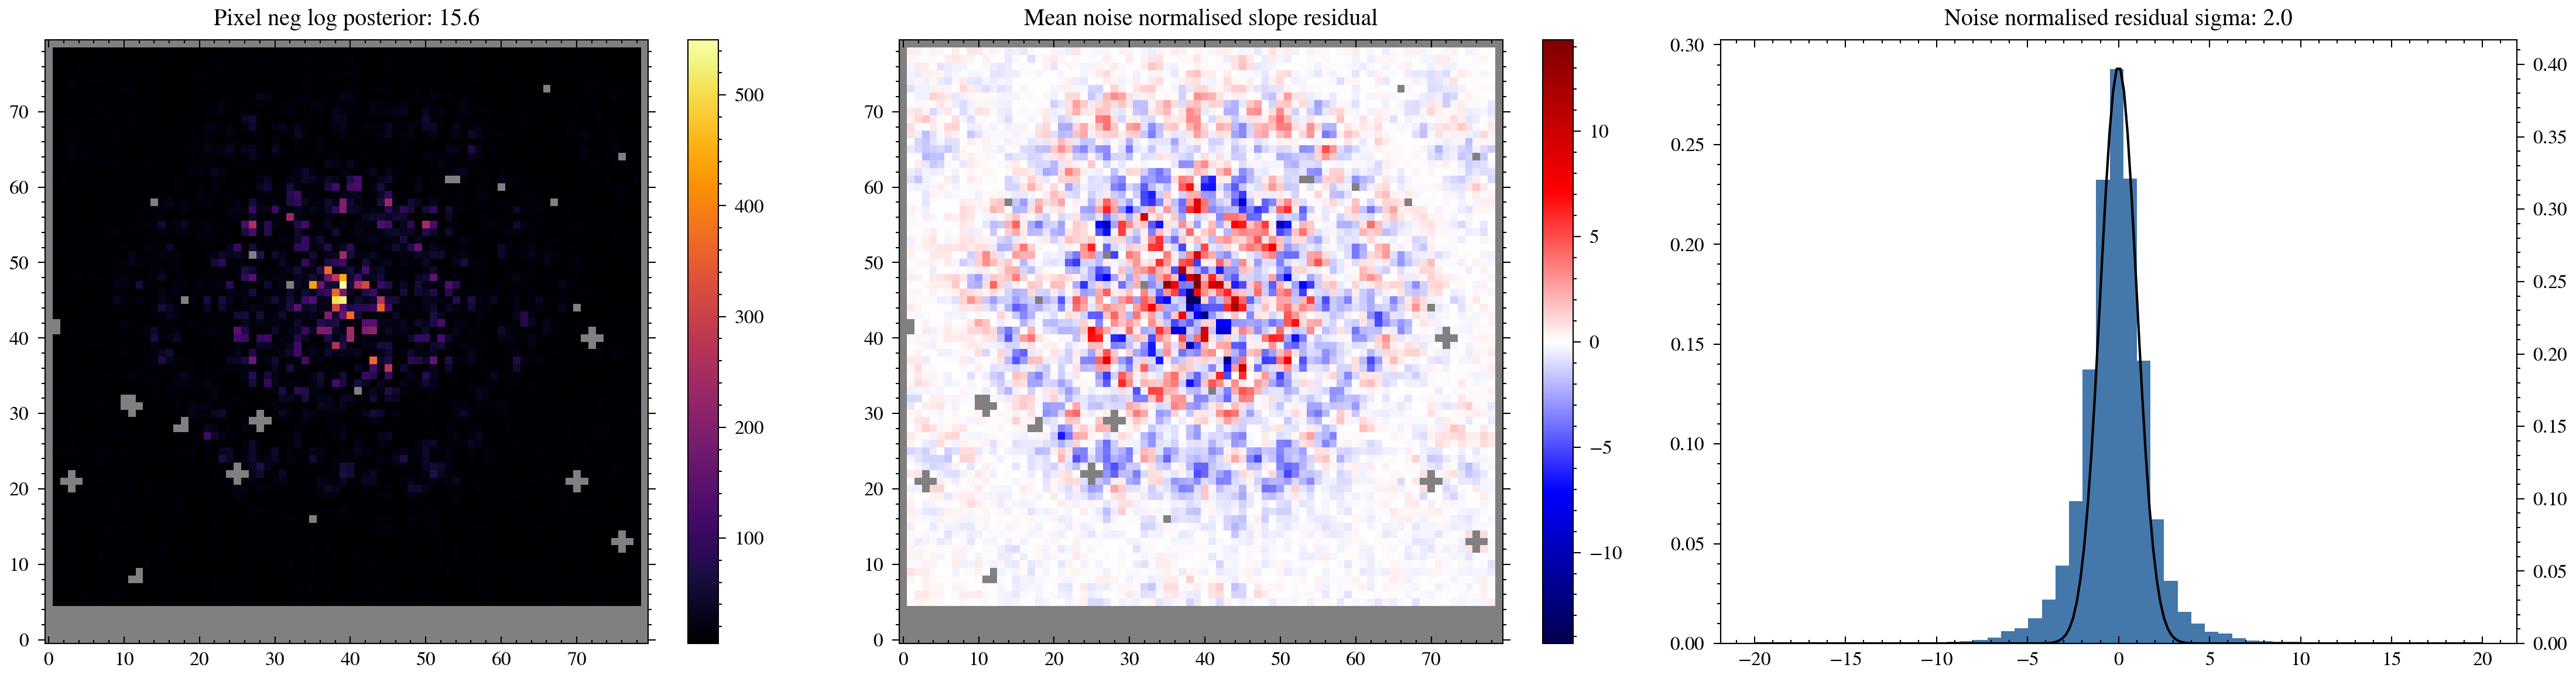

File 01242_004_03_03_1
Star TD-CAL-HD-123991
Filter F430M
nints 507
ngroups 20



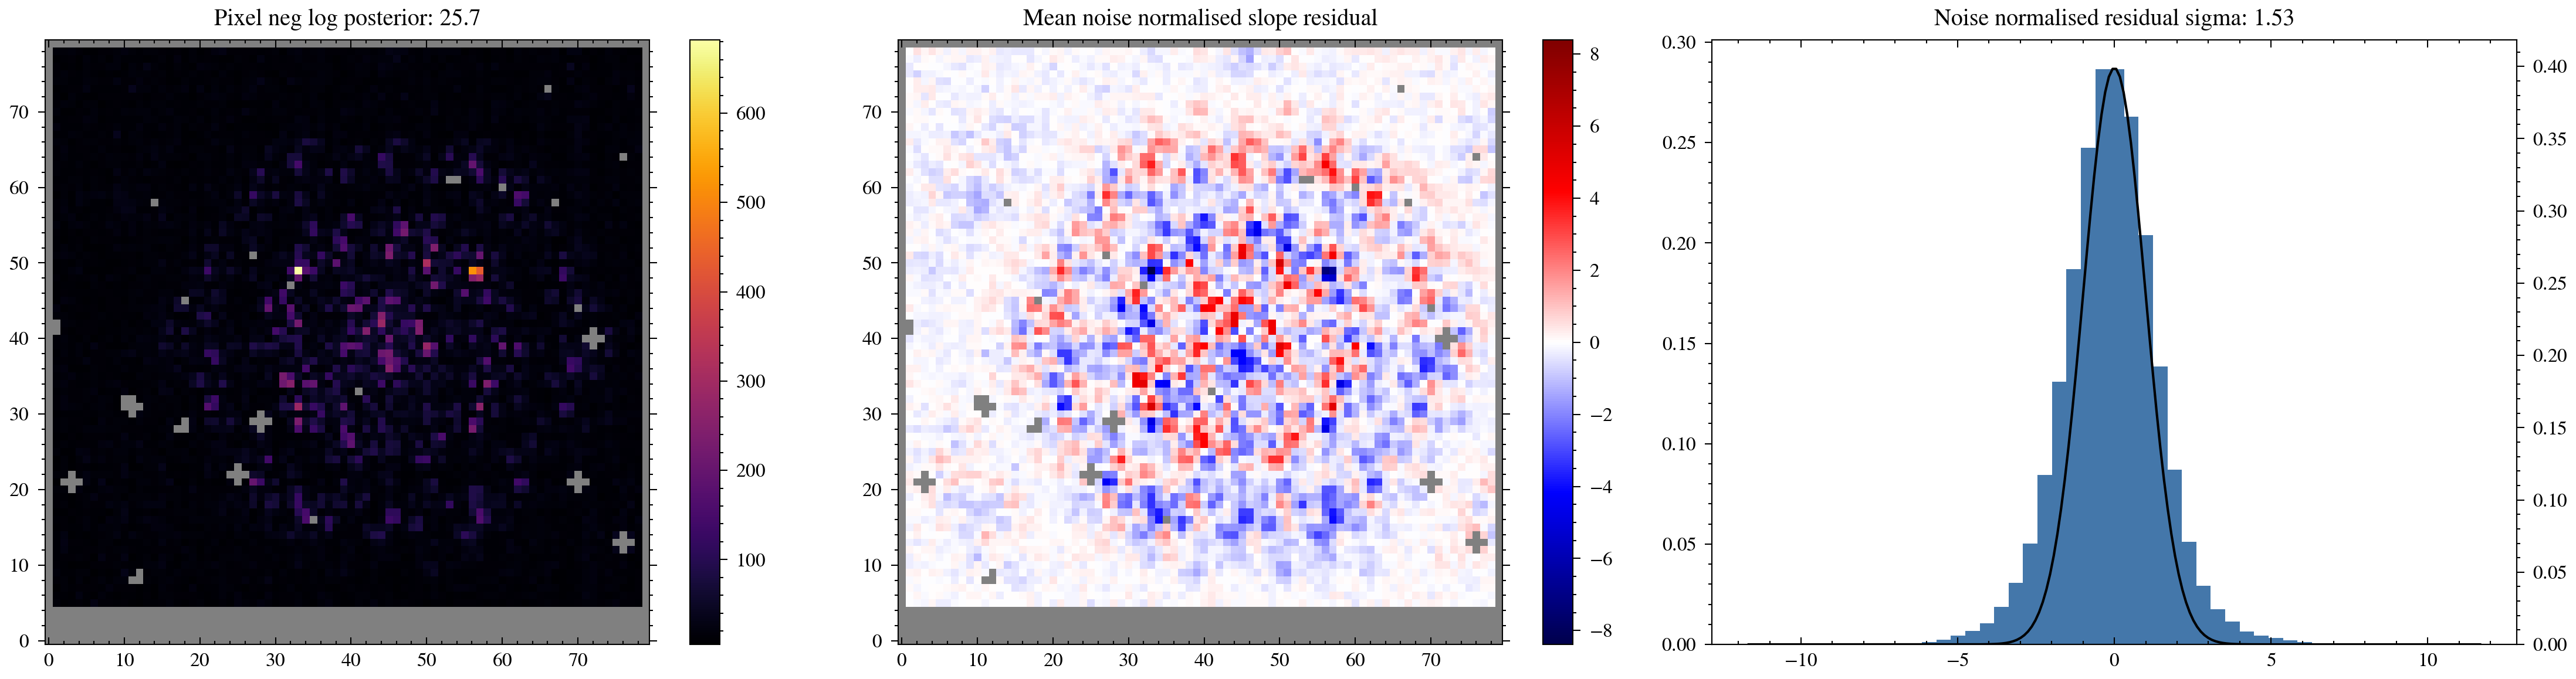

File 01093_018_04_03_1
Star HD-36805
Filter F380M
nints 122
ngroups 3



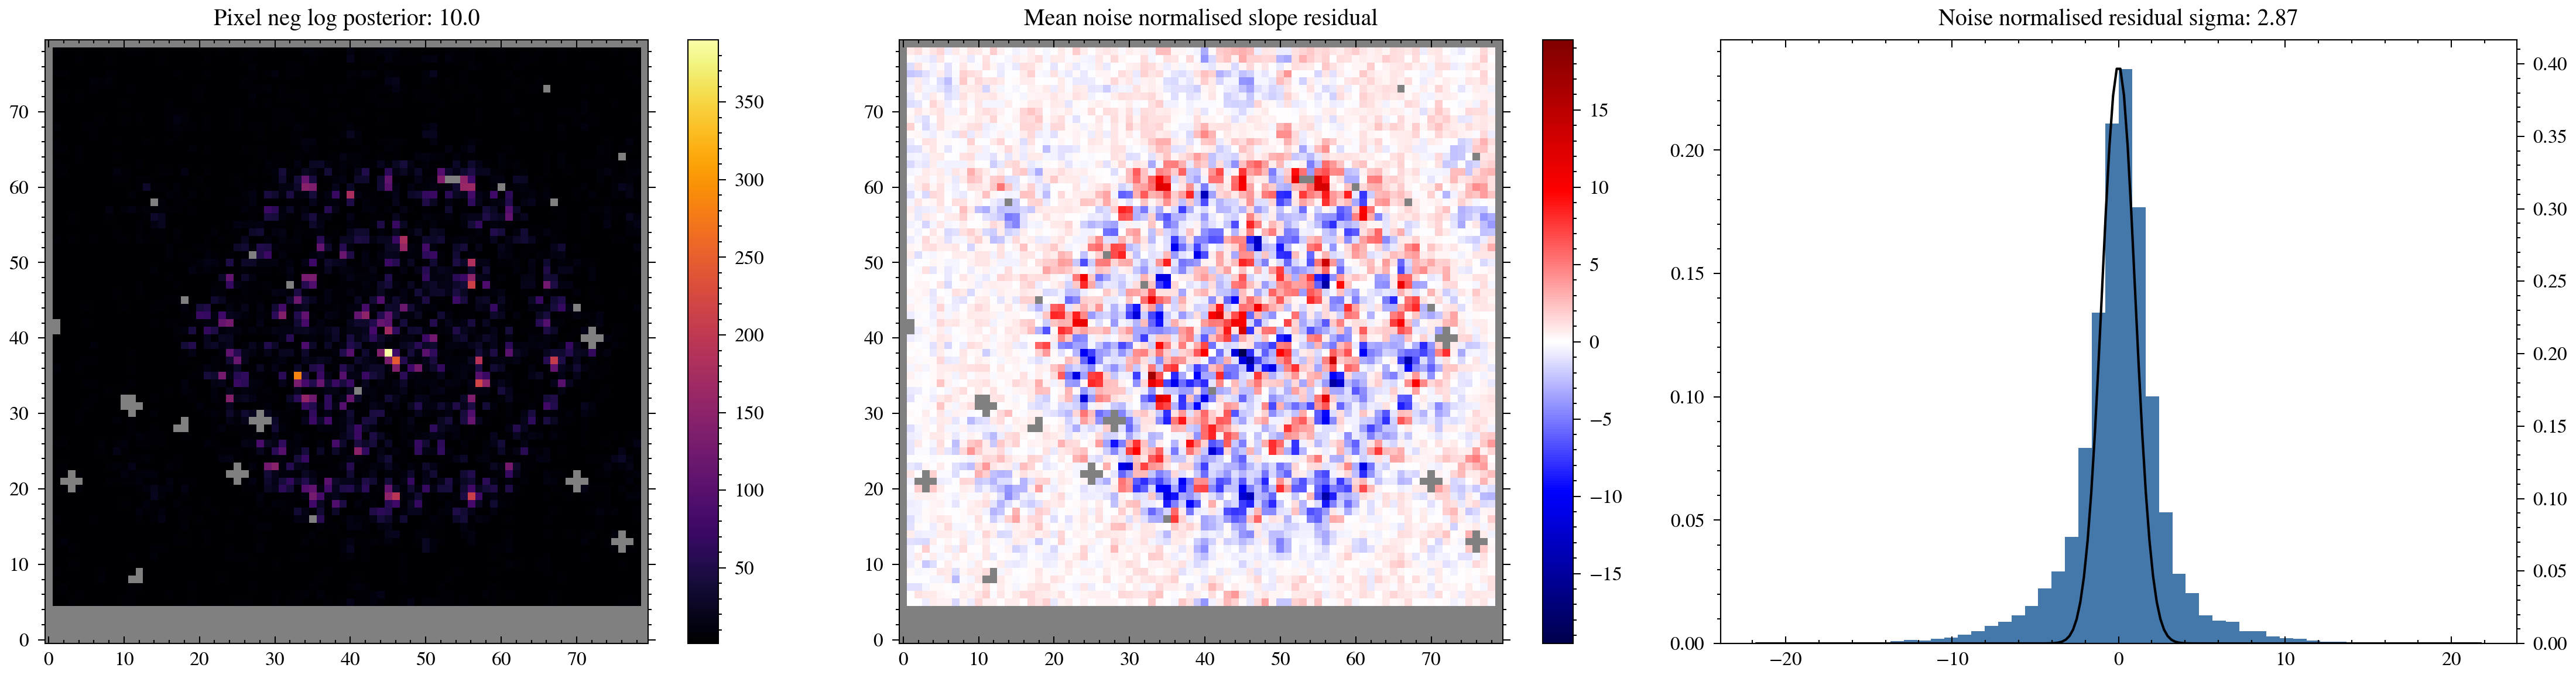

File 01843_002_01_05_1
Star HD-205827
Filter F380M
nints 7800
ngroups 3



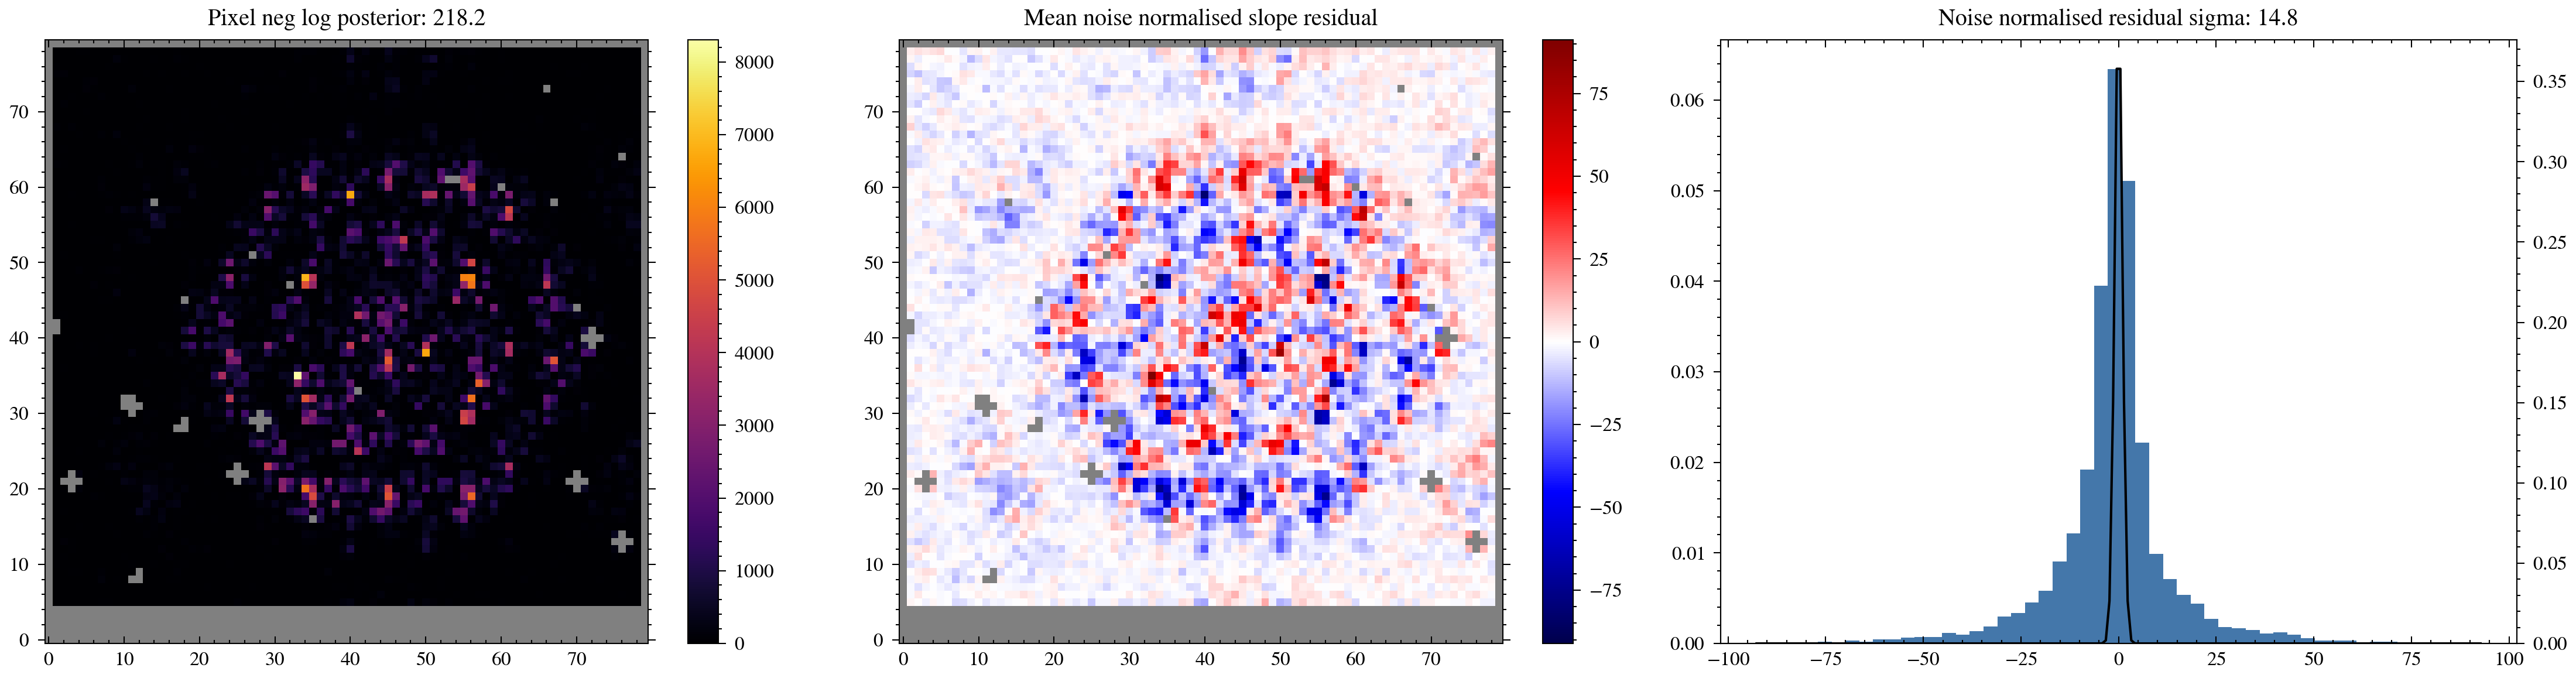

File 01242_004_04_03_1
Star TD-CAL-HD-123991
Filter F380M
nints 612
ngroups 10



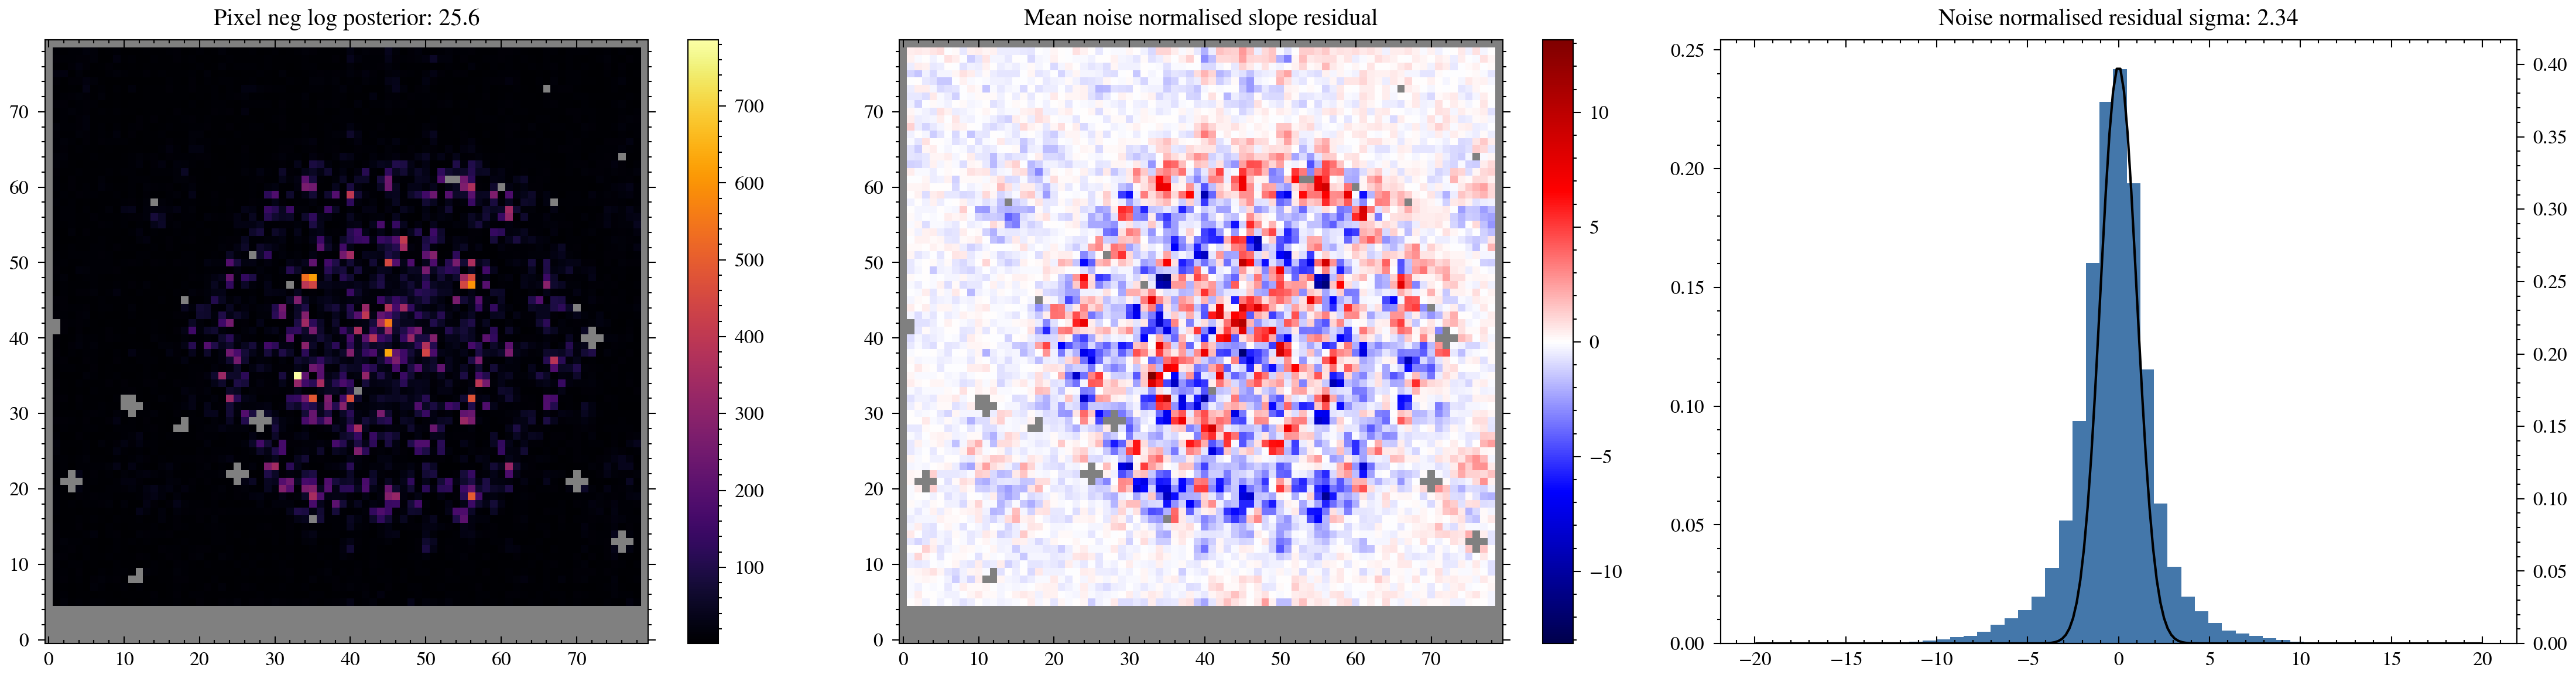

In [14]:
amigo.plotting.plot(result.history, save_path=save_path)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp, save_path=None)

## Pixel sensitivity and non-linearity

In [15]:
# inferno_r = get_cmap("inferno_r")

# badpix_bool = badpix.astype(bool)

# FF = result.model.FF.at[badpix_bool].set(np.nan)
# non_lin = result.model.non_linearity[0].at[badpix_bool].set(np.nan)

# ff_xs = np.linspace(np.nanmin(FF), np.nanmax(FF), 100) - 1
# ff_l2 = np.exp(-((ff_xs / 0.035) ** 2))

# med_nl = np.nanmedian(non_lin)
# nl_xs = np.linspace(np.nanmin(non_lin), np.nanmax(non_lin), 100)
# nl_l2 = np.exp(-(((nl_xs - med_nl) / 0.025) ** 2))


# fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# ax1, ax2, ax3, ax4 = axes.flatten()

# # Pixel sensitivity
# ax1.set_title("Sensitivity (FF)")
# im1 = ax1.imshow(FF, seismic, norm=mpl.colors.CenteredNorm(1))
# fig.colorbar(im1, ax=ax1)

# # Linear (imshow)
# ax2.set_title("Non-linearity")
# im2 = ax2.imshow(non_lin, inferno_r, vmax=None)
# fig.colorbar(im2, ax=ax2)

# # FF histogram
# ax3.set_title("FF")
# ax3.hist(FF[::2].flatten(), bins=100, density=True)
# ax3.hist(FF[1::2].flatten(), bins=100, alpha=0.75, density=True)
# ax3.plot(ff_xs + 1, 25 * ff_l2, label="L2", c="k")

# # Linear histogram
# ax4.set_title("non-linearity")
# ax4.hist(non_lin[::2].flatten(), bins=100)
# ax4.hist(non_lin[1::2].flatten(), bins=100, alpha=0.75)
# ax4.plot(nl_xs, 150 * nl_l2, label="L2", c="k")

# fig.tight_layout()
# if save_flag:
#     plt.savefig(os.path.join(save_path, "pixels.png"), dpi=300)
# plt.show()

## Wavefront

In [16]:
# optics = result.model.optics
# pupil_mask = result.model.optics.pupil_mask

# rms = lambda x: np.sqrt(np.nanmean(np.square(x)))

# if "aberrations" in optimisers.keys():
#     for prog in ["4481", "8330", "1093", "1843", "1242"]:
#         print(prog)
#         cal_aberrations = {key: val for key, val in result.state.aberrations.items() if prog in key}  # NOTE USE ALL 
        
#         fig, axes = plt.subplots(2, 3, figsize=(12, 6))
#         for i, key in enumerate(cal_aberrations):
        
#             coeffs = result.model.aberrations[key]
#             full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
#             flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()
        
#             mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
        
#             full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
#             flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)
        
#             full_abb -= np.nanmean(full_abb)
#             flat_abb -= np.nanmean(flat_abb)
        
#             ax_top = axes[0, i]
#             ax_bot = axes[1, i]
        
#             v = np.nanmax(np.abs(full_abb))
#             ax_top.set_title(f"{key} — Full OPD (RMS: {rms(full_abb):.2f} nm)")
#             im_top = ax_top.imshow(full_abb, cmap=seismic, vmin=-v, vmax=v)
#             fig.colorbar(im_top, ax=ax_top, label="OPD (nm)")
        
#             v = np.nanmax(np.abs(flat_abb))
#             ax_bot.set_title(f"{key} — FLAT OPD (RMS: {rms(flat_abb):.2f} nm)")
#             im_bot = ax_bot.imshow(flat_abb, cmap=seismic, vmin=-v, vmax=v)
#             fig.colorbar(im_bot, ax=ax_bot, label="OPD (nm)")
        
#         fig.tight_layout()
#         if save_flag:
#             plt.savefig(os.path.join(save_path, f"wavefront_{prog}.png"), dpi=300)
#             plt.close()
#         else:
#             plt.show()

## Pupil and beam

In [17]:
# null_pupil_mask = model.optics.pupil_mask.multiply("primary_beam", 0.0).multiply("distortion", 0.0)
# null_mask = null_pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

# pupil_mask = result.model.optics.pupil_mask
# mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

# fig, ax = plt.subplots(figsize=(3, 2))

# ax.set_title("Pupil & Beam Distortions")
# im = ax.imshow(mask - null_mask, cmap="berlin", norm=mpl.colors.CenteredNorm())
# fig.colorbar(im, ax=ax)

# fig.tight_layout()
# if save_flag:
#     plt.savefig(os.path.join(save_path, "pupil_beam.png"), dpi=300)
#     plt.close()
# else:
#     plt.show()

## Slope plots

In [18]:
# # Create the cal exposure dictionaries
# cal_dict = {}
# for exp in calpsf_exposures:
#     if exp.filter not in cal_dict:
#         cal_dict[exp.filter] = []
#     cal_dict[exp.filter].append(exp)

# # Create the val exposure dictionaries
# val_dict = {}
# for exp in val_exposures:
#     if exp.filter not in val_dict:
#         val_dict[exp.filter] = []
#     val_dict[exp.filter].append(exp)

In [19]:
# from amigo.misc import convert_adjacent_to_true

# if save_flag:
#     this_save_path = os.path.join(save_path, "slope_res")
#     os.mkdir(this_save_path)

# exp_types = ["cal", "val"] if val_flag else ["cal"]
# exp_dicts = [cal_dict, val_dict] if val_flag else [cal_dict]

# for typ, dic in zip(exp_types, exp_dicts):
#     for idx, (filt, _) in enumerate(dic.items()):
#         n = 2
#         k = 2 * n + 1
    
#         for exp in dic[filt]:

#             print(exp)
    
#             slopes = exp(result.model)
#             im = slopes.sum(0)
#             peak_pix = im == np.nanmax(im)
#             peak_map = convert_adjacent_to_true(peak_pix, corners=True, n=n)
    
#             ######### plotting #########
#             max_loc = np.argwhere(peak_pix)[0][::-1]
#             square = mpl.patches.Rectangle(max_loc - np.array([2.5, 2.5]), 5, 5, color="r", fill=False)
    
#             fig, ax = plt.subplots(figsize=(3, 2))
#             c = ax.imshow(im, "cividis", norm=mpl.colors.PowerNorm(0.5))
#             ax.add_patch(square)
#             ax.set(title=f"Cropping: {filt}")
#             ax.axis("off")
#             fig.colorbar(c, ax=ax, label="Counts")
#             if save_flag:
#                 plt.savefig(os.path.join(this_save_path, f"{typ}_crop_{filt}.png"), dpi=300)
#                 plt.close()
#             else:
#                 plt.show()
#             ############################
    
#             ind = np.where(peak_map)
#             model_slopes = slopes[:, *ind].reshape(-1, k, k)
#             data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
#             data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5
    
#             xs = np.arange(len(slopes))
    
#             fig, axes = plt.subplots(k, k, figsize=(3 * k, 3 * k), sharex="col")
#             # fig.suptitle(filt)
    
#             for i in range(k):
#                 for j in range(k):
#                     ax = axes[i, j]
    
#                     if i == k - 1:
#                         ax.set_xlabel("Slope Index")
#                     else:
#                         ax.tick_params(labelbottom=False)
#                     if j == 0:
#                         ax.set_ylabel("Slope (e- / group)")
    
#                     ax.errorbar(
#                         xs, data_slopes[:, i, j], yerr=data_std[:, i, j],
#                         marker='o', capsize=5, label="Data",
#                     )
#                     ax.errorbar(
#                         xs, model_slopes[:, i, j],
#                         marker='x', capsize=5, label="Model"
#                     )
#                     ax.legend()
    
#             # fig.tight_layout()
#             if save_flag:
#                 plt.savefig(os.path.join(this_save_path, f"{typ}_slope_{filt}.png"), dpi=300)
#                 plt.close()
#             else:
#                 plt.show()


In [20]:
# if not type(trainer) == amigo.fitting.Trainer:
#     nn = result.best_state.params["nn_weights"]
#     nnf = result.state.params["nn_weights"]
#     # nni = model.nn_weights
#     nnh = np.array(result.history["nn_weights"][-n_batch:])
#     nnhm = nnh.mean(0)
#     nnh0 = nnh[0]
#     nnh1 = nnh[1]
    
#     print(nn.shape)
#     nbins = 300
#     # plt.hist(nn, bins=nbins, alpha=0.7, label="best_state")
#     # plt.hist(nnf, bins=nbins, alpha=0.7, label="state")
#     # plt.hist(nnhm, bins=nbins, alpha=0.7, label="history_mean")
#     plt.hist(nnh0, bins=nbins, alpha=0.7, label="history[0]")
#     plt.hist(nnh1, bins=nbins, alpha=0.7, label="history[1]")
#     # plt.hist(nni, bins=nbins, alpha=0.7, label="initial")
#     plt.xlim(-1, 1)
#     plt.legend()
#     plt.show()